# Lecture 16: Working with Date/Time Data (Time Series)
## One-Step Date Parsing + Indexing
- parse_dates=['col'] + index_col=['col'] together in read_csv() — converts the column
  to a proper datetime type AND sets it as the index, in a single step
- Previously this took two separate steps (pd.to_datetime() then set_index())

In [3]:
import pandas as pd
df = pd.read_csv("../datasets/aapl.csv", parse_dates=['Date'], index_col=['Date'])
df.head(3)


C:\Users\ap504\AppData\Local\Temp\ipykernel_6480\3533912306.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("../datasets/aapl.csv", parse_dates=['Date'], index_col=['Date'])


,Open,High,Low,Close,Volume
Date,,,,,
2017-07-07,142.90,144.75,142.90,144.18,19201712
2017-07-06,143.02,143.50,142.41,142.73,24128782
2017-07-05,143.69,144.79,142.72,144.09,21569557


In [4]:
df.index

DatetimeIndex(['2017-07-07', '2017-07-06', '2017-07-05', '2017-07-03',
               '2017-06-30', '2017-06-29', '2017-06-28', '2017-06-27',
               '2017-06-26', '2017-06-23',
               ...
               '2016-07-22', '2016-07-21', '2016-07-20', '2016-07-19',
               '2016-07-18', '2016-07-15', '2016-07-14', '2016-07-13',
               '2016-07-12', '2016-07-11'],
              dtype='datetime64[ns]', name='Date', length=251, freq=None)

## Partial String Indexing (only works with .loc, on a DatetimeIndex)
- df.loc["2017"]        → entire year (all rows in 2017) → returns a DataFrame
- df.loc["2017-01"]     → entire month (all rows in Jan 2017) → returns a DataFrame
- df.loc["2017-01-05"]  → a single specific day → returns a Series (one row)
- MUST use .loc — without it, Pandas looks for a literal column named "2017-01"
  and throws a KeyError, since it doesn't know this is meant as date-based lookup

In [ ]:
df.loc["2017-01"]

In [ ]:
df.loc["2017-01"].Close

In [ ]:
df.loc["2017-01"].Close.mean()

In [ ]:
df.loc["2017-2-1"]

## sort_index() — Fixing Chronological Order
- Stock/financial data often comes in reverse order (latest date first)
- sort_index() sorts by the index (dates here) into proper oldest→newest order
- Like any transform, store the result in a NEW variable — sort_index() does not
  modify the original DataFrame unless inplace=True is explicitly passed

In [ ]:
new_df = df.sort_index()
new_df.loc["2017-01-01":"2017-01-05"]

## resample() — Time-Based Aggregation
- Groups data by a time period and applies an aggregate function — conceptually the
  same as pd.Grouper(freq=...) used earlier inside pivot_table, but simpler syntax
  when applied directly on a Series/column
- Common frequency codes: 'D' Daily, 'W' Weekly, 'M' Monthly, 'QE' Quarterly (Quarter End), 'Y' Yearly
- resample('freq').mean() → average per period
- resample('freq').sum()  → total per period

In [ ]:
new_df.Close.resample('M').mean()

## Visualization with resample()
- %matplotlib inline → makes charts render directly inside the Jupyter notebook
- .resample(...).mean().plot() → line chart (default)
- .resample(...).mean().plot(kind='bar') → bar chart instead

In [ ]:
%matplotlib inline
new_df.Close.resample('QE').mean().plot()

<Axes: xlabel='Date'>

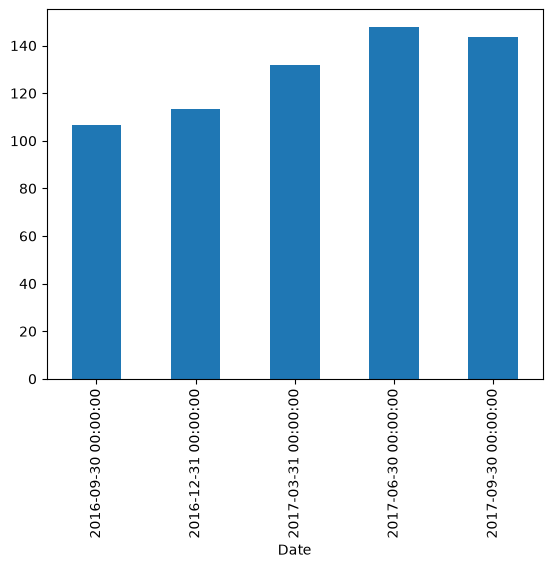

In [6]:
new_df.Close.resample('QE').mean().plot(kind='bar')